In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 21
mpl.rcParams['ytick.labelsize'] = 21


### Plotting the horizon

In [2]:
# read horizon data from a file for the plot
horizon_data = pd.read_csv('horizon_data_et.csv')

In [3]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [4]:
from matplotlib import colors
def color_to_hex_with_alpha(color_input, opacity):
    """
    Convert a color (hex or name) + opacity (0.0–1.0)
    into HEX with alpha (#RRGGBBAA)
    """

    if not (0.0 <= opacity <= 1.0):
        raise ValueError("Opacity must be between 0.0 and 1.0")

    # Convert color name or hex to RGB (0–1 range)
    r, g, b = colors.to_rgb(color_input)

    # Convert to 0–255
    r, g, b = int(r * 255), int(g * 255), int(b * 255)

    # Convert opacity to alpha
    alpha = round(opacity * 255)

    return "#{:02X}{:02X}{:02X}{:02X}".format(r, g, b, alpha)

In [5]:
hatch_color = color_to_hex_with_alpha(ska_color_purple, 0.1)

In [6]:
# ska redshift bands
# band 1: 350-1050MHz --> z = 0.35 - 3.06
# band 2: 950-1760MHz --> z = 0.0 - 0.49

band1_zmin = 0.35
band1_zmax = 3.06
band2_zmin = 0.0
band2_zmax = 0.49

ska_low_zmin = 3.06
ska_low_zmax = 27.41

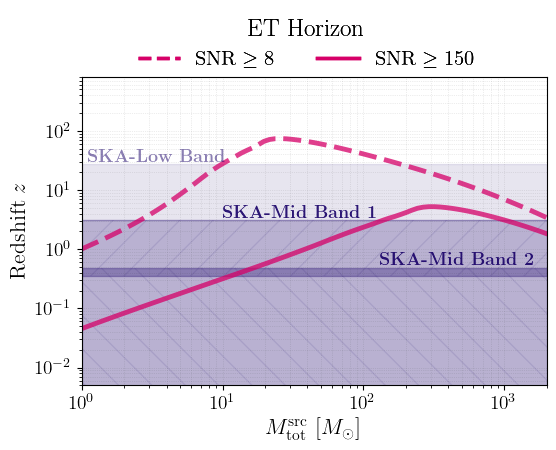

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

my_lnwdth = 3.5

ax.loglog(horizon_data['Total_Source_Frame_Mass_SolarMass'], horizon_data['Redshift_Horizon_ET_snr8'], label='ET', color=ska_color_pink, linewidth=my_lnwdth, linestyle='dashed', alpha=0.75)
ax.loglog(horizon_data['Total_Source_Frame_Mass_SolarMass'], horizon_data['Redshift_Horizon_ET_snr150'], label='ET', color=ska_color_pink, linewidth=my_lnwdth, linestyle='solid', alpha=0.75)

# plot horizontal bands for SKA bands
ax.fill_between([1, 2000], band1_zmin, band1_zmax, color=ska_color_purple, alpha=0.3)
ax.fill_between([1, 2000], band2_zmin, band2_zmax, color=ska_color_purple, alpha=0.3)
ax.fill_between([1, 2000], ska_low_zmin, ska_low_zmax, color=ska_color_purple, alpha=0.1)

# hatched structure
ax.fill_between([1, 2000], band1_zmin, band1_zmax, facecolor='none', hatch='/', alpha=0.1, linewidth=0.01, edgecolor=hatch_color)
ax.fill_between([1, 2000], band2_zmin, band2_zmax, facecolor='none', hatch='\\', alpha=0.1, linewidth=0.01, edgecolor=hatch_color)


# add text labels for SKA bands slighlty above the bands
ax.text(10.1, band1_zmax*1.1, r'\rm \textbf{SKA-Mid Band 1}', color=ska_color_purple, fontsize=13, alpha=0.9, fontweight='bold')
ax.text(130.1, band2_zmax*1.1, r'\rm \textbf{SKA-Mid Band 2}', color=ska_color_purple, fontsize=13, alpha=0.9, fontweight='bold')
ax.text(1.1, ska_low_zmax*1.1, r'\rm \textbf{SKA-Low Band}', color=ska_color_purple, fontsize=13, alpha=0.5, fontweight='bold')


# create custom legend handles 
detector_handles = [
    Line2D([0], [0], color=ska_color_pink, lw=my_lnwdth-1, linestyle='dashed', label=r'\rm $\mathrm{SNR} \ge 8$'),
    Line2D([0], [0], color=ska_color_pink, lw=my_lnwdth-1, linestyle='solid', label=r'\rm $\mathrm{SNR} \ge 150$')
]

ax.set_xlabel(r'$M_{\rm tot}^{\rm src}$ $[M_{\odot}]$', fontsize=16)
ax.set_ylabel(r'\rm Redshift $z$', fontsize=16)
ax.grid(which='both', linestyle='dotted', linewidth=0.5, alpha=0.15, color='black')
ax.tick_params(axis='both', labelsize=14)

# add legends
legend1 = fig.legend(title = r'\rm ET Horizon', handles=detector_handles, loc='upper center',
                     fontsize=15, bbox_to_anchor=(0.5, 1.075), title_fontsize=18,
                     ncol=2, frameon=False)

ax.add_artist(legend1)

ax.set_ylim(0.005, 800)
ax.set_xlim(1, 2000)

plt.savefig('horizon.pdf', bbox_inches='tight')
plt.show()
